In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
df = pd.read_excel(r"C:\Users\Lekhaa\Downloads\iphone_synthetic_dataset.xlsx")

In [4]:
df

,Observation_ID,Year,iPhone_Model,Storage,Color,Country,Currency,Production_Cost_USD,Selling_Price_USD,Gross_Margin_Pct,Markup_Pct,Units_Sold,Country_Price_Multiplier
0,1,2022,iPhone 14,512GB,Blue,France,EUR,375.69,1153.09,67.42,206.93,438,1.12
1,2,2024,iPhone 15 Pro Max,128GB,Blue,Australia,AUD,413.51,1539.61,73.14,272.33,1886,1.15
2,3,2023,iPhone SE (3rd Gen),256GB,Starlight,Japan,JPY,208.65,526.31,60.36,152.25,2481,0.95
3,4,2024,iPhone 15 Pro,512GB,Gold,Singapore,SGD,421.71,1516.47,72.19,259.60,508,1.08
4,5,2023,iPhone SE (3rd Gen),512GB,Midnight,India,INR,276.47,741.91,62.74,168.35,601,1.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...
220,221,2021,iPhone 12,512GB,Starlight,Japan,JPY,334.55,853.55,60.80,155.13,344,0.95
221,222,2020,iPhone 11,128GB,Red,Japan,JPY,231.61,651.16,64.43,181.15,1927,0.95
222,223,2022,iPhone 13 Pro,256GB,Blue,United Kingdom,GBP,361.97,1304.72,72.26,260.45,907,1.08
223,224,2020,iPhone 11,128GB,Red,France,EUR,256.64,739.94,65.32,188.32,1348,1.12


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225 entries, 0 to 224
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Observation_ID            225 non-null    int64  
 1   Year                      225 non-null    int64  
 2   iPhone_Model              225 non-null    object 
 3   Storage                   225 non-null    object 
 4   Color                     225 non-null    object 
 5   Country                   225 non-null    object 
 6   Currency                  225 non-null    object 
 7   Production_Cost_USD       225 non-null    float64
 8   Selling_Price_USD         225 non-null    float64
 9   Gross_Margin_Pct          225 non-null    float64
 10  Markup_Pct                225 non-null    float64
 11  Units_Sold                225 non-null    int64  
 12  Country_Price_Multiplier  225 non-null    float64
dtypes: float64(5), int64(3), object(5)
memory usage: 23.0+ KB


In [6]:
df.describe()

,Observation_ID,Year,Production_Cost_USD,Selling_Price_USD,Gross_Margin_Pct,Markup_Pct,Units_Sold,Country_Price_Multiplier
count,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,225.00000,225.000000
mean,113.000000,2022.155556,326.661467,1044.289200,66.896267,212.587644,1842.92000,1.108311
std,65.096083,1.266949,64.415043,353.016647,6.133916,58.992071,2274.80948,0.125814
min,1.000000,2020.000000,175.010000,424.640000,44.740000,80.950000,122.00000,0.950000
25%,57.000000,2021.000000,284.370000,779.980000,63.040000,170.540000,510.00000,1.030000
50%,113.000000,2022.000000,329.960000,994.250000,67.420000,206.960000,1056.00000,1.080000
75%,169.000000,2023.000000,366.610000,1304.720000,71.040000,245.330000,2139.00000,1.120000
max,225.000000,2024.000000,490.600000,2076.890000,79.300000,383.090000,17015.00000,1.450000


In [7]:
model_price = df.groupby('iPhone_Model')['Selling_Price_USD'].mean().sort_values(ascending=False)
model_price

iPhone_Model
iPhone 15 Pro Max      1565.012000
iPhone 15 Pro          1489.159286
iPhone 14 Pro          1331.015556
iPhone 13 Pro          1305.437368
iPhone 12 Pro          1197.340833
iPhone 13              1002.754286
iPhone 15               974.352000
iPhone 14               957.617857
iPhone 12               847.465500
iPhone 11               746.832667
iPhone SE (3rd Gen)     595.638261
iPhone SE (2nd Gen)     542.069444
Name: Selling_Price_USD, dtype: float64

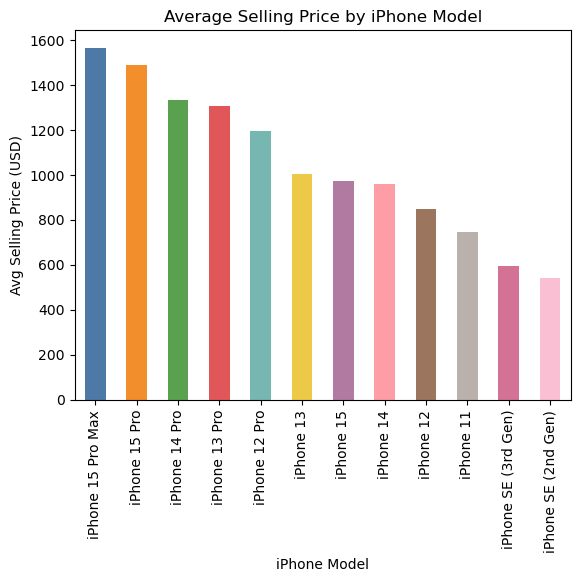

In [8]:
model_price.plot(kind='bar', color=['#4E79A7','#F28E2B','#59A14F','#E15759',
                                          '#76B7B2','#EDC948','#B07AA1','#FF9DA7',
                                          '#9C755F','#BAB0AC','#D37295','#FABFD2'])
plt.title("Average Selling Price by iPhone Model")
plt.xlabel("iPhone Model")
plt.ylabel("Avg Selling Price (USD)")
plt.show()

In [9]:
model_prod = df.groupby('iPhone_Model')['Production_Cost_USD'].mean().sort_values()
model_prod

iPhone_Model
iPhone SE (2nd Gen)    223.958889
iPhone SE (3rd Gen)    239.764783
iPhone 11              264.275333
iPhone 12              303.293500
iPhone 13              311.333571
iPhone 14              334.970714
iPhone 12 Pro          336.311667
iPhone 15              345.379333
iPhone 13 Pro          361.730000
iPhone 14 Pro          376.704444
iPhone 15 Pro          403.649286
iPhone 15 Pro Max      430.232000
Name: Production_Cost_USD, dtype: float64

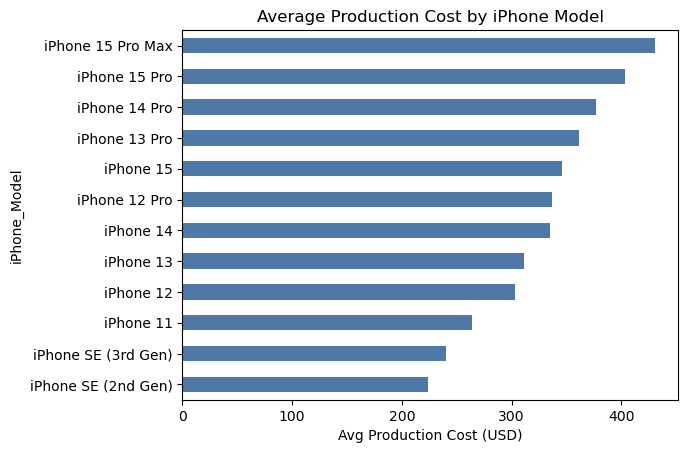

In [10]:
model_prod.plot(kind='barh', color='#4E79A7')
plt.title("Average Production Cost by iPhone Model")
plt.xlabel("Avg Production Cost (USD)")
plt.show()

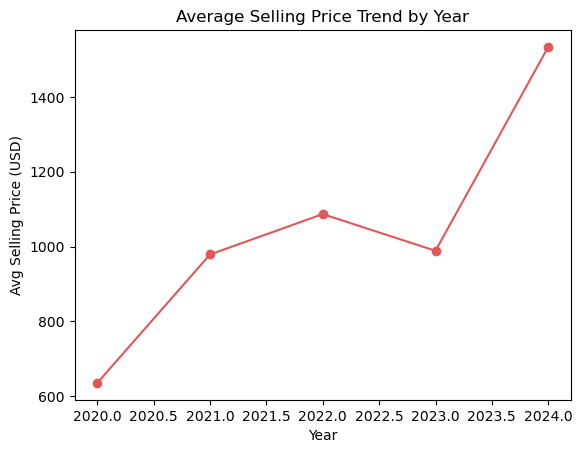

In [11]:
yearly = df.groupby('Year')['Selling_Price_USD'].mean()
yearly.plot(kind='line', marker='o', color='#E15759')
plt.title("Average Selling Price Trend by Year")
plt.xlabel("Year")
plt.ylabel("Avg Selling Price (USD)")
plt.show()

In [12]:
yearly_prod = df.groupby('Year')['Production_Cost_USD'].mean()
yearly_prod

Year
2020    242.284545
2021    315.675313
2022    332.455738
2023    321.020000
2024    419.286176
Name: Production_Cost_USD, dtype: float64

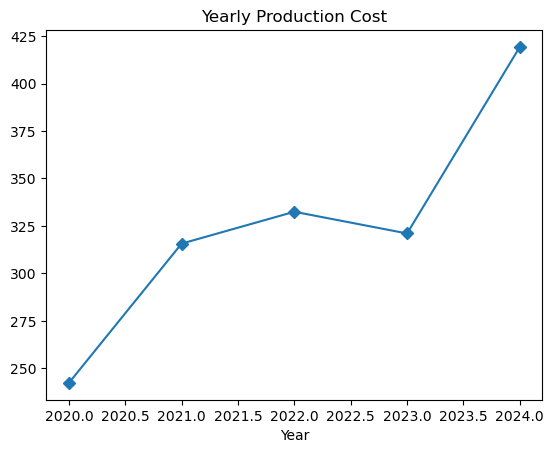

In [13]:
yearly_prod.plot(kind='line',marker='D')
plt.title("Yearly Production Cost")
plt.show()

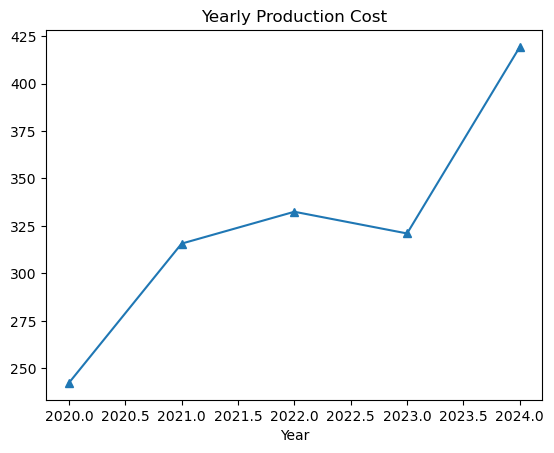

In [14]:
yearly_prod.plot(kind='line',marker='^')
plt.title("Yearly Production Cost")
plt.show()

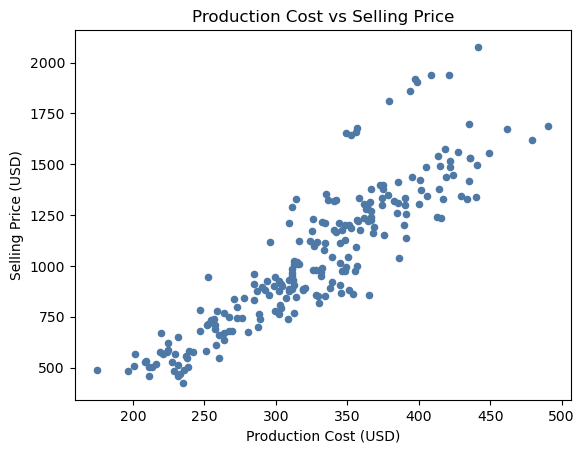

In [15]:
df.plot(kind='scatter', x='Production_Cost_USD', y='Selling_Price_USD',
         color='#4E79A7')
plt.title("Production Cost vs Selling Price")
plt.xlabel("Production Cost (USD)")
plt.ylabel("Selling Price (USD)")
plt.show()

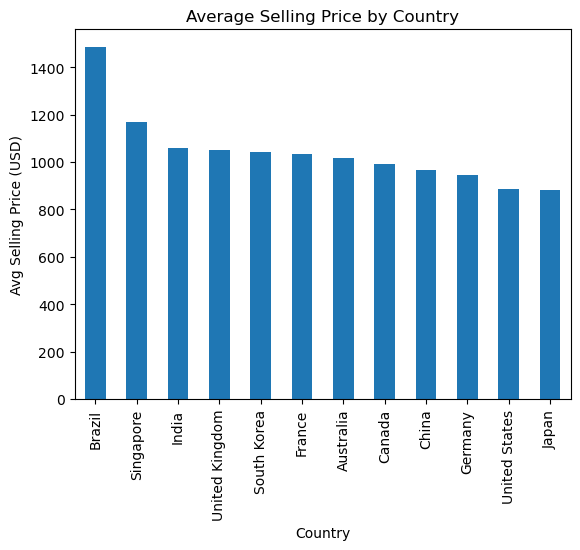

In [16]:
country_price = df.groupby('Country')['Selling_Price_USD'].mean().sort_values(ascending=False)
country_price.plot(kind='bar')
plt.title("Average Selling Price by Country")
plt.xlabel("Country")
plt.ylabel("Avg Selling Price (USD)")
plt.show()

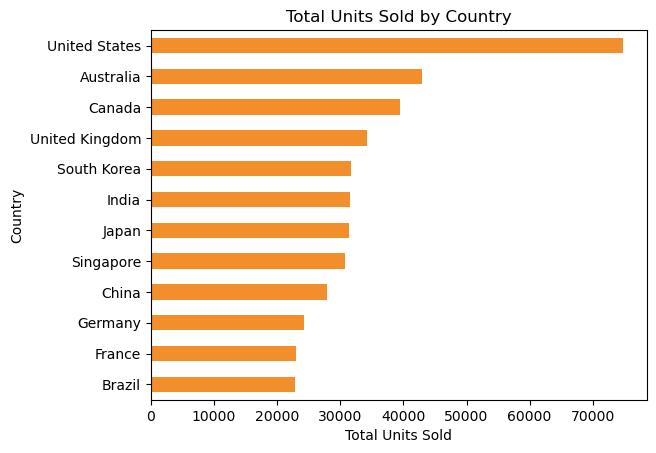

In [17]:
country_units = df.groupby('Country')['Units_Sold'].sum().sort_values()
country_units.plot(kind='barh', color='#F28E2B')
plt.title("Total Units Sold by Country")
plt.xlabel("Total Units Sold")
plt.show()

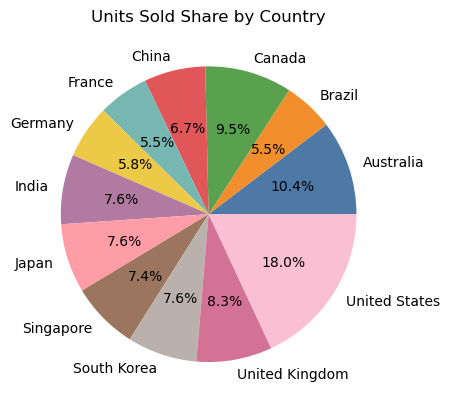

In [18]:
country_units_pie = df.groupby('Country')['Units_Sold'].sum()
country_units_pie.plot(kind='pie', autopct='%1.1f%%',
                       colors=['#4E79A7','#F28E2B','#59A14F','#E15759','#76B7B2',
                                '#EDC948','#B07AA1','#FF9DA7','#9C755F','#BAB0AC',
                                '#D37295','#FABFD2'])
plt.title("Units Sold Share by Country")
plt.ylabel("")
plt.show()

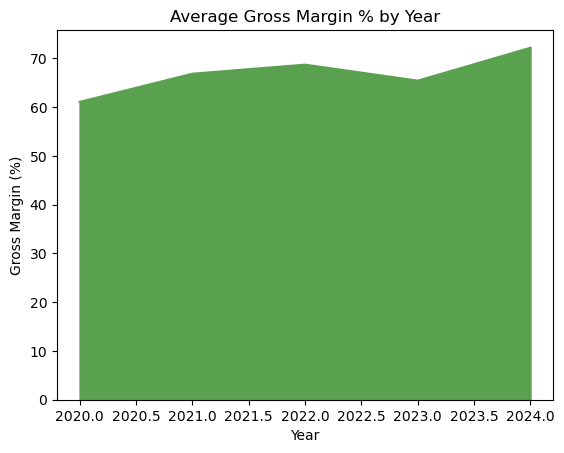

In [19]:
yearly_margin = df.groupby('Year')['Gross_Margin_Pct'].mean()
yearly_margin.plot(kind='area', color='#59A14F')
plt.title("Average Gross Margin % by Year")
plt.xlabel("Year")
plt.ylabel("Gross Margin (%)")
plt.show()

In [20]:
df

,Observation_ID,Year,iPhone_Model,Storage,Color,Country,Currency,Production_Cost_USD,Selling_Price_USD,Gross_Margin_Pct,Markup_Pct,Units_Sold,Country_Price_Multiplier
0,1,2022,iPhone 14,512GB,Blue,France,EUR,375.69,1153.09,67.42,206.93,438,1.12
1,2,2024,iPhone 15 Pro Max,128GB,Blue,Australia,AUD,413.51,1539.61,73.14,272.33,1886,1.15
2,3,2023,iPhone SE (3rd Gen),256GB,Starlight,Japan,JPY,208.65,526.31,60.36,152.25,2481,0.95
3,4,2024,iPhone 15 Pro,512GB,Gold,Singapore,SGD,421.71,1516.47,72.19,259.60,508,1.08
4,5,2023,iPhone SE (3rd Gen),512GB,Midnight,India,INR,276.47,741.91,62.74,168.35,601,1.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...
220,221,2021,iPhone 12,512GB,Starlight,Japan,JPY,334.55,853.55,60.80,155.13,344,0.95
221,222,2020,iPhone 11,128GB,Red,Japan,JPY,231.61,651.16,64.43,181.15,1927,0.95
222,223,2022,iPhone 13 Pro,256GB,Blue,United Kingdom,GBP,361.97,1304.72,72.26,260.45,907,1.08
223,224,2020,iPhone 11,128GB,Red,France,EUR,256.64,739.94,65.32,188.32,1348,1.12


In [21]:
df.head()

,Observation_ID,Year,iPhone_Model,Storage,Color,Country,Currency,Production_Cost_USD,Selling_Price_USD,Gross_Margin_Pct,Markup_Pct,Units_Sold,Country_Price_Multiplier
0,1,2022,iPhone 14,512GB,Blue,France,EUR,375.69,1153.09,67.42,206.93,438,1.12
1,2,2024,iPhone 15 Pro Max,128GB,Blue,Australia,AUD,413.51,1539.61,73.14,272.33,1886,1.15
2,3,2023,iPhone SE (3rd Gen),256GB,Starlight,Japan,JPY,208.65,526.31,60.36,152.25,2481,0.95
3,4,2024,iPhone 15 Pro,512GB,Gold,Singapore,SGD,421.71,1516.47,72.19,259.60,508,1.08
4,5,2023,iPhone SE (3rd Gen),512GB,Midnight,India,INR,276.47,741.91,62.74,168.35,601,1.20


In [22]:
df.tail()

,Observation_ID,Year,iPhone_Model,Storage,Color,Country,Currency,Production_Cost_USD,Selling_Price_USD,Gross_Margin_Pct,Markup_Pct,Units_Sold,Country_Price_Multiplier
220,221,2021,iPhone 12,512GB,Starlight,Japan,JPY,334.55,853.55,60.80,155.13,344,0.95
221,222,2020,iPhone 11,128GB,Red,Japan,JPY,231.61,651.16,64.43,181.15,1927,0.95
222,223,2022,iPhone 13 Pro,256GB,Blue,United Kingdom,GBP,361.97,1304.72,72.26,260.45,907,1.08
223,224,2020,iPhone 11,128GB,Red,France,EUR,256.64,739.94,65.32,188.32,1348,1.12
224,225,2023,iPhone SE (3rd Gen),256GB,Starlight,Germany,EUR,258.17,611.81,57.80,136.98,599,1.12


In [24]:
df.shape

(225, 13)

In [25]:
df["Price_Margin"] = df["Selling_Price_USD"] - df["Production_Cost_USD"]
df

,Observation_ID,Year,iPhone_Model,Storage,Color,Country,Currency,Production_Cost_USD,Selling_Price_USD,Gross_Margin_Pct,Markup_Pct,Units_Sold,Country_Price_Multiplier,Price_Margin
0,1,2022,iPhone 14,512GB,Blue,France,EUR,375.69,1153.09,67.42,206.93,438,1.12,777.40
1,2,2024,iPhone 15 Pro Max,128GB,Blue,Australia,AUD,413.51,1539.61,73.14,272.33,1886,1.15,1126.10
2,3,2023,iPhone SE (3rd Gen),256GB,Starlight,Japan,JPY,208.65,526.31,60.36,152.25,2481,0.95,317.66
3,4,2024,iPhone 15 Pro,512GB,Gold,Singapore,SGD,421.71,1516.47,72.19,259.60,508,1.08,1094.76
4,5,2023,iPhone SE (3rd Gen),512GB,Midnight,India,INR,276.47,741.91,62.74,168.35,601,1.20,465.44
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220,221,2021,iPhone 12,512GB,Starlight,Japan,JPY,334.55,853.55,60.80,155.13,344,0.95,519.00
221,222,2020,iPhone 11,128GB,Red,Japan,JPY,231.61,651.16,64.43,181.15,1927,0.95,419.55
222,223,2022,iPhone 13 Pro,256GB,Blue,United Kingdom,GBP,361.97,1304.72,72.26,260.45,907,1.08,942.75
223,224,2020,iPhone 11,128GB,Red,France,EUR,256.64,739.94,65.32,188.32,1348,1.12,483.30


In [26]:
df1 = df[["Production_Cost_USD", "Selling_Price_USD"]]
df1

,Production_Cost_USD,Selling_Price_USD
0,375.69,1153.09
1,413.51,1539.61
2,208.65,526.31
3,421.71,1516.47
4,276.47,741.91
...,...,...
220,334.55,853.55
221,231.61,651.16
222,361.97,1304.72
223,256.64,739.94


In [27]:
plt.scatter(df1["Production_Cost_USD"], df1["Selling_Price_USD"])
plt.xlabel("Production Cost (USD)")
plt.ylabel("Selling Price (USD)")

Text(0, 0.5, 'Selling Price (USD)')

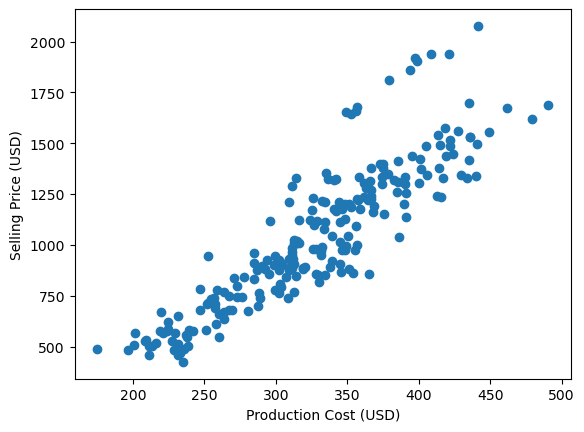

In [28]:
plt.show()

In [29]:
df1.corr()

,Production_Cost_USD,Selling_Price_USD
Production_Cost_USD,1.000000,0.889055
Selling_Price_USD,0.889055,1.000000


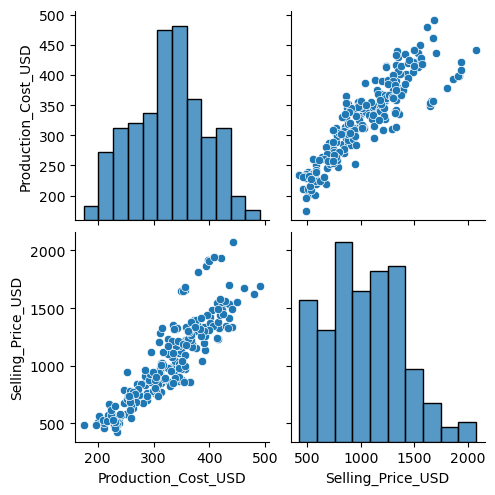

In [30]:
import seaborn as sns
sns.pairplot(df1)
plt.show()

In [31]:
X = df1[["Production_Cost_USD"]]
Y = df1["Selling_Price_USD"]
X.shape

(225, 1)

In [32]:
Y.shape

(225,)

In [33]:
from sklearn.model_selection import train_test_split

In [34]:
X_test, X_train, Y_test, Y_train = train_test_split(X, Y, test_size=0.25, random_state=42)

In [35]:
X_train

,Production_Cost_USD
9,378.54
184,363.57
120,366.33
207,299.55
148,351.26
214,308.63
182,418.92
86,309.43
178,345.17
175,316.12


In [36]:
X_test

,Production_Cost_USD
119,311.25
183,366.61
194,319.27
10,266.99
69,461.58
...,...
106,288.48
14,436.04
92,325.72
179,433.59


In [37]:
Y_train

9      1350.07
184    1291.90
120    1378.93
207     947.61
148     879.77
214     740.19
182    1438.92
86      884.27
178     905.08
175    1121.69
68      982.70
15     1119.37
200    1447.59
25      839.11
30      670.99
45      896.12
60     1168.14
176     792.35
101    1161.10
165    1240.09
79      859.13
18      848.99
167    1343.97
152     762.42
96      879.27
82      566.63
193     668.76
172     780.54
220     853.55
104     470.44
118    1327.35
75      981.86
16      579.54
198    1172.60
201     579.46
117     866.71
195     688.12
114    1218.06
111    1174.71
144     735.67
141    1202.17
213    1176.64
143     958.88
222    1304.72
142    1212.94
163     950.74
67      922.52
55     1810.34
124     568.05
127    1099.63
209    1412.38
84     1313.72
93     1657.88
97     1376.23
115    1397.85
38      906.99
24     1200.51
Name: Selling_Price_USD, dtype: float64

In [38]:
Y_test

119     963.60
183    1224.11
194     884.01
10      681.09
69     1673.67
        ...   
106     763.44
14     1531.42
92      980.13
179    1331.23
102    1226.50
Name: Selling_Price_USD, Length: 168, dtype: float64

In [39]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

In [40]:
X_train

array([[ 1.07714851],
       [ 0.77815531],
       [ 0.83328031],
       [-0.500505  ],
       [ 0.53228982],
       [-0.31915174],
       [ 1.88365121],
       [-0.30317348],
       [ 0.41065531],
       [-0.16955527],
       [-0.2602319 ],
       [-0.5684126 ],
       [ 1.98291616],
       [-1.07811912],
       [-1.22012591],
       [-0.68605255],
       [ 0.34234825],
       [-0.41881614],
       [ 0.87042976],
       [ 0.83188221],
       [ 0.81610368],
       [-0.2156925 ],
       [ 2.1019542 ],
       [-0.45416804],
       [-0.64750499],
       [-2.45444654],
       [-2.0951354 ],
       [-0.50669657],
       [ 0.1985439 ],
       [-1.82550226],
       [-0.20550636],
       [ 0.06392706],
       [-1.47058514],
       [ 0.01579255],
       [-1.70207019],
       [ 0.41964308],
       [-1.34775227],
       [ 0.15360505],
       [ 0.4268333 ],
       [-1.39468841],
       [ 0.46957515],
       [ 0.68288493],
       [-0.80369249],
       [ 0.74619879],
       [ 0.39527624],
       [ 0

In [41]:
X_test = scaler.transform(X_test)
X_test

array([[-0.26682294],
       [ 0.8388727 ],
       [-0.10664087],
       [-1.1508202 ],
       [ 2.73569196],
       [-0.10624142],
       [-0.79090988],
       [-2.31064219],
       [-1.55686775],
       [-0.24285555],
       [ 0.13503032],
       [ 1.29285503],
       [ 0.32397325],
       [-1.85725905],
       [ 0.07251537],
       [-1.7410172 ],
       [-0.34691397],
       [-0.43739087],
       [-1.35753895],
       [ 0.62076944],
       [ 0.40226673],
       [ 0.03077217],
       [ 1.52793519],
       [-0.75156342],
       [-2.06857155],
       [-0.1987156 ],
       [ 0.3441458 ],
       [ 2.33603572],
       [ 2.31426534],
       [-2.00925225],
       [-0.2694194 ],
       [ 1.3294053 ],
       [-1.55946422],
       [ 0.18995559],
       [ 1.48159823],
       [-0.93771015],
       [-0.42600636],
       [-2.00266122],
       [-1.33656748],
       [-1.10867754],
       [ 1.02022596],
       [-2.31603486],
       [ 0.1829651 ],
       [-0.27061777],
       [ 0.56085096],
       [ 0

In [44]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression(n_jobs=-1)
regression.fit(X_train, Y_train)

LinearRegression(n_jobs=-1)

In [45]:
print("Coefficient or slope:", regression.coef_)
print("Intercept:", regression.intercept_)

Coefficient or slope: [241.67947209]
Intercept: 1036.5957894736846


In [46]:
plt.scatter(X_train, Y_train)
plt.plot(X_train, regression.predict(X_train), color='red')

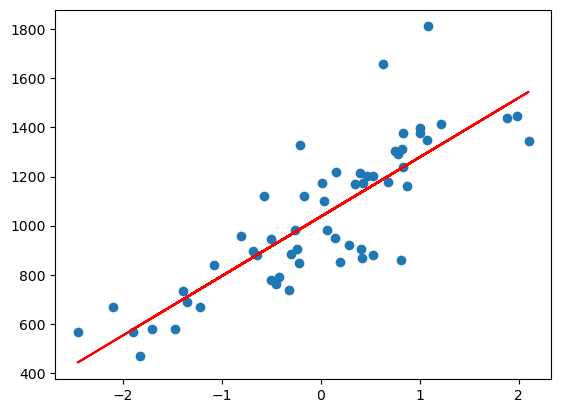

In [47]:
plt.show()

In [50]:
Y_pred = regression.predict(X_test)
Y_pred

array([ 972.11016318, 1239.33410011, 1010.82287947,  758.46617025,
       1697.75637775, 1010.91941991,  845.44910636,  478.16100374,
        660.33281335,  977.90258955, 1069.22984546, 1349.05230976,
       1114.89347341,  587.73440274, 1054.12126665,  615.82767067,
        952.75380503,  930.88739545,  708.50649273, 1186.62302006,
       1133.81539958, 1044.03279071, 1405.86635849,  854.95833967,
        536.66451017,  988.57030814, 1119.76876561, 1601.16766789,
       1595.90621393,  551.00076545,  971.48265032, 1357.88575999,
        659.70530049, 1082.50415591, 1394.66766749,  809.9704948 ,
        933.63879798,  552.59368271,  713.57486581,  768.65118663,
       1283.16345971,  476.85770781, 1080.81469821,  971.193029  ,
       1172.14195412, 1200.04214117,  987.9910655 ,  740.99235067,
       1329.74422183,  962.40784899,  785.01479115,  996.39008375,
       1084.6763158 ,  910.42082224,  725.20798879,  979.49550681,
        314.47668833,  614.28302364,  588.41018582, 1409.00392

In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [52]:
mse  = mean_squared_error(Y_test, Y_pred)
mae  = mean_absolute_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
print("MSE :", mse)
print("MAE :", mae)
print("RMSE:", rmse)

MSE : 25722.946410464727
MAE : 111.30021906703526
RMSE: 160.38374733888944


In [53]:
from sklearn.metrics import r2_score
score = r2_score(Y_test, Y_pred)
print("R² Score:", score)

R² Score: 0.8125116156793871


In [54]:
import statsmodels.api as sm
model = sm.OLS(Y_train, X_train).fit()
prediction = model.predict(X_test)
print(prediction)

[ -64.4856263   202.73831063  -25.77291    -278.12961923  661.16058828
  -25.67636956 -191.14668311 -558.43478573 -376.26297612  -58.69319992
   32.63405598  312.45652029   78.29768393 -448.86138674   17.52547718
 -420.7681188   -83.84198445 -105.70839403 -328.08929674  150.02723059
   97.2196101     7.43700124  369.27056902 -181.6374498  -499.93127931
  -48.02548134   83.17297614  564.57187841  559.31042445 -485.59502402
  -65.11313916  321.28997052 -376.89048898   45.90836643  358.07187802
 -226.62529468 -102.9569915  -484.00210677 -323.02092366 -267.94460284
  246.56767023 -559.73808167   44.21890874  -65.40276047  135.54616464
  163.4463517   -48.60472398 -295.6034388   293.14843236  -74.18794048
 -251.58099833  -40.20570573   48.08052633 -126.17496723 -311.38780068
  -57.10028266 -722.11910114 -422.31276583 -448.18560366  372.40813331
  -75.05680444  434.29055512  600.38838152 -179.07912815  536.67169136
  424.63651115  141.62821234  240.72697363 -318.82141454 -232.36945084
  322.

In [55]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:      Selling_Price_USD   R-squared (uncentered):                   0.050
Model:                            OLS   Adj. R-squared (uncentered):              0.033
Method:                 Least Squares   F-statistic:                              2.970
Date:                Mon, 23 Feb 2026   Prob (F-statistic):                      0.0904
Time:                        23:00:21   Log-Likelihood:                         -477.37
No. Observations:                  57   AIC:                                      956.7
Df Residuals:                      56   BIC:                                      958.8
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------